# Can RAG pass an AI class? Evaluating question answering on lecture transcripts

*Alessio Pittiglio*

## 📋 Table of contents:

- [0. Import and setup](#0-import-and-setup)
- [1. Introduction](#1-introduction)
- [2. Dataset and transcription](#2-dataset-and-transcription)
- [3. The ragqa library](#3-the-ragqa-library)
- [4. MCQ dataset generation](#4-mcq-dataset-generation)
- [5. RAG system and experimental setup](#5-rag-system-and-experimental-setup)
- [6. Results](#6-results)
- [7. Error analysis](#7-error-analysis)
- [8. NIAH](#8-niah)
- [9. Conclusions](#9-conclusions)

## ⚙️ 0. Import and setup

In [ ]:
import matplotlib.pyplot as plt
import pandas as pd
import torch

from ragqa import config
from ragqa.embedding_utils import encode_texts, get_embedding_model
from ragqa.llm_interface import load_model, generate_response
from ragqa.prompt_loader import load_prompt
from ragqa.rag_core import (
    create_client,
    get_or_create_collection,
    query_collection,
)

In [ ]:
device = "cuda" if torch.cuda.is_available() else "cpu"

## 1. Introduction

This project shows whether RAG can answer exam-style questions based on lecture transcripts. The goal is to evaluate the performance and limitations of retrieval compared to local LLMs. The evaluation is based on a manually curated MCQA dataset, and accuracy is used as the main metric.

All models were run locally on a dedicated workstation with the following specifications:
- CPU: Intel Core i5-12600KF (12th Gen)
- GPU: NVIDIA RTX 3090
- RAM: 64 GB
- OS: Linux
- Python: 3.10.16

## 2. Dataset and transcription

### 2.1 Lecture Selection

In this section, I briefly introduce how the transcripts were obtained. I selected three courses that were, in a sense, representative of the topics covered in the Master's Degree in Artificial Intelligence. Specifically, I chose the course Fundamentals of AI and Knowledge Representation, which is divided into three modules and covers core AI topics such as search, planning, and knowledge representation, for a total of about 50 lectures; the Deep Learning course, which also includes lectures on Computer Vision and Reinforcement Learning, for about 24 lectures; and finally the Natural Language Processing course (about 22 lectures). This resulted in a total of 96 lectures, corresponding to approximately 153 hours of transcribed audio. Some lectures were uploaded in multiple parts, for this reason, the number of transcripts is 107.

### 2.2 Transcription 

All lectures were transcribed using Whisper large-v2, an open-source speech-to-text model developed by OpenAI. Each lecture was associated with metadata in JSON format, including the course name, the professor's name, the lecture date, and the lecture number. Whisper large-v2 was used with a silence threshold to reduce hallucinations: if a silence longer than 2 seconds was detected, the transcription process was stopped.

### 2.3 Data Cleaning

Next, the files were inspected to assess: (1) the quality of the transcripts and (2) whether a cleaning phase could be applied. First of all, occasional errors are present, especially with more technical terms. For example, instead of Prolog, the model sometimes transcribes Prologue, or it makes mistakes with people's names. These issues could be addressed by providing an initial prompt to Whisper as context. More invasive approaches, such as using another LLM to correct the lectures, were excluded; instead, we relied on the ability of LLMs to correctly understand the content even when some words are misspelled. Another problem is that repetitions sometimes appear at the end of the transcription, with phrases or words repeated countless times due to model hallucinations. A script was therefore used to post-process the transcripts. For each file, the script applies the following transformations in sequence: it removes repeated short words (very short words, one or two letters long, repeated at least five consecutive times), collapses repeated sentences, and removes sequences of repeated symbols.

## 3. The `ragqa` library

The library covers several aspects: data processing, embeddings, LLM interface, evaluation, prompt loading, and the RAG core.

### 3.1 Data processing

Regarding data processing, we implemented a function to load the transcripts and their corresponding metadata, which returns a list of dictionaries, one for each lecture. In addition, a chunking function is provided. This function splits the text into chunks, optionally with overlap between them. Chunking is performed at the token level, using the tokenizer of the embedding model. The text is extracted directly from the original string rather than from the decoded version. 

### 3.2 Embeddings

The embedding component provides functions to load the embedding model and to transform texts into embeddings. By default, a batch size of 32 is used to process texts in batches. Each embedding is normalized to unit norm, making the dot product equivalent to cosine similarity.

### 3.3 LLM interface

As for the use of the LLM, we relied on the Python binding of `llama.cpp` by Georgi Gerganov. In particular, the official binding was not used, as it is not frequently updated, but rather a version maintained by Andrei Betlen ([link](https://github.com/abetlen/llama-cpp-python)). The advantage of using `llama.cpp` is that it allows some of the model layers to be offloaded to the CPU, thereby reducing the load on the GPU. This makes it possible both to keep GPU temperatures within acceptable ranges and to run very large models, even larger than the available VRAM. In addition, a function is provided to clean the output by removing thinking tokens. The response generation function allows the user to choose whether to return the raw output or the cleaned version.

### 3.4 RAG core


The RAG core provides a set of functions to manage ChromaDB, which was chosen as the vector database. These functions allow the creation of a persistent database through a Chroma client stored on disk. It also provides a function to retrieve an existing collection or create it if it does not already exist, while another function allows the insertion of documents into the collections. To prevent overflow, documents are inserted in batches. Finally, there is also a function to perform similarity-based search that normalizes the query embeddings.

### 3.5 Evaluation

The evaluation functions are designed to extract the model's answer from the LLM output. First, we check whether the response begins with a letter from A to D. If not, we search the text for the first standalone letter between A and D. Finally, an additional function computes the accuracy for each experiment and saves the results in CSV format.

## 4. MCQ dataset generation

The goal was to obtain a dataset of about 200 questions. For this reason, given 107 lectures, around 300 questions were initially generated. Subsequently, poorly generated or irrelevant questions were discarded, resulting in a curated dataset of about 200 questions. The most naïve approach would have been to generate one question for each chunk. Each lecture is approximately 15,000 tokens long, and with chunks of 1,000 tokens this corresponds to about 15 chunks per lecture. With 107 lectures, this results in about 1,605 chunks. Assuming an inference time of 20–30 seconds per chunk, this process would take up to 48,150 seconds, or roughly 13 hours. For this reason, this approach was discarded.

### 4.1 Chunk selection

In the end, I chose an approach in which the model first selects the three most relevant chunks. The prompt asks the model to identify, among the provided chunks, those that are most suitable for generating high-quality multiple-choice questions to evaluate a RAG system. It prioritizes chunks that contain definitions, properties, or procedures rather than introductory or narrative parts, and returns only a JSON object with the selected IDs. For each selected chunk, a second prompt is used to generate an MCQ. The model is also required to provide the evidence. Specifically, the evidence field must be an exact copy of a sentence from the excerpt. The questions are generated using `gpt-oss-20b`, an OpenAI model with 21B parameters, which is particularly strong at instruction following.

```
You are assisting in the construction of an evaluation dataset for a RAG system.

Below are numbered chunks extracted from a university lecture of a Master's program in AI.

Your task is to select exactly 3 chunks that are most suitable for generating high-quality multiple-choice questions.

Selection criteria:
1. Prefer chunks that introduce concepts, definitions, properties, and procedures.
2. The chunk should contain information that allows you to write a question that can be answered clearly, with plausible distractors and whose answer is grounded in the text.
3. Avoid introductory passages, rhetorical examples, jokes, anecdotes, and historical references.
4. Prefer chunks that cover different conceptual levels.
5. If two chunks cover overlapping content, select only one.

Chunks:
{chunks_block}

Return strictly in the following JSON format:

{
  "selected_chunks": [id1, id2, id3]
}
```

### 4.2 Question generation

The script then verifies that the evidence provided by the model is actually present in the chunk, using either exact matching or fuzzy matching with RapidFuzz. This step is necessary because LLM outputs can be fragile. The model often makes small changes, especially at the beginning or end of the evidence, such as replacing conjunctions, turning commas into periods, or capitalizing the first letter even when it is lowercase in the original text. To address this issue, once the evidence has been found through fuzzy matching, the generated evidence is replaced with the original sentence from the chunk.

### 4.3 Manual curation

There was also a phase in which we manually curated the questions. To do this, we relied on closed LLMs such as ChatGPT, using a structured prompt to evaluate each question across different aspects, assign a score, and retain only those exceeding a certain threshold. The prompt determined whether each question should be kept or discarded. Six criteria were considered: grounding; context dependence, to avoid questions that can be solved without retrieval; clarity; distractor quality; domain relevance, to exclude questions about narrative content; and cognitive level, to move the benchmark beyond recall. In total, 193 out of 287 questions were retained, corresponding to about 67% of the original set.

## 5. RAG system and experimental setup

![Pipeline RAG](/home/apittiglio/Projects/bdtm-project/figure/rag_pipeline.png)

In [100]:
collection_name = "mpnet_256_clean"
embedding_name = "sentence-transformers/all-mpnet-base-v2"
top_k = 3

model_path = config.MODELS_DIR / "microsoft_Phi-4-mini-instruct-Q4_K_M.gguf"

model_config = {
    "n_ctx": 8192,
    "n_gpu_layers:": 23,
    "flash_attn": True,
    "verbose": False,
}

generation_config = {
    "temperature": 0,
    "top_p": 1,
    "max_tokens": 10,
}

In [101]:
def build_context_block(chunks):
    context_sections = [
        f"CONTEXT {idx + 1}\n{chunk}"
        for idx, chunk in enumerate(chunks)
    ]
    return "\n".join(context_sections) + "\nEND CONTEXT\n\n"

In [102]:
def build_choices_block(choices):
    return "\n".join(f"{key}. {choices[key]}" for key in sorted(choices))

In [104]:
chroma_client = create_client(config.VECTOR_STORE_DIR)
embedding_model = get_embedding_model(embedding_name, device)
llm = load_model(model_path, config=model_config)
collection = get_or_create_collection(chroma_client, collection_name)

llama_context: n_ctx_per_seq (8192) < n_ctx_train (131072) -- the full capacity of the model will not be utilized


In [105]:
question = (
    "Which term describes the scenario where a model performs a task "
    "specified by a prompt without any gradient updates?"
)

options = {
    "A": "Few-shot learning",
    "B": "Fine-tuning",
    "C": "Zero-shot learning",
    "D": "Instruction tuning",
}

print("\nQUESTION:")
print(question)
print("\nOPTIONS:")
for k, v in options.items():
    print(f"{k}. {v}")



QUESTION:
Which term describes the scenario where a model performs a task specified by a prompt without any gradient updates?

OPTIONS:
A. Few-shot learning
B. Fine-tuning
C. Zero-shot learning
D. Instruction tuning


In [106]:
query_embedding = encode_texts([question], embedding_model, normalize=True)[0]

search_results = query_collection(
    collection,
    query_embeddings=[query_embedding.tolist()],
    n_results=top_k,
)

contexts = search_results["documents"][0]

print("\nRETRIEVED CONTEXTS:")
for i, ctx in enumerate(contexts, 1):
    print(f"\nContext {i}")
    print(ctx)


RETRIEVED CONTEXTS:

Context 1
the input, but also with a template that includes some other additional information. And the idea that you tell the model what to do and get an output is in the... So without gradient updates, without doing fine tuning with gradient updates, is part of a bigger, let's say, concept that is called in-context learning. So let's look at what in-context learning means. In-context learning is as opposed to learning by gradient updates. So what you do is, in the classic case of fine tuning, where you do gradient updates, you have a model that is trained by showing examples and updating the parameters, updating the gradient. And this you do that using a large corpus of example tasks. So here, for example, you give some example, input-output, and then you update the model, or a batch of examples, then you update the model, and then you give some other examples, update the model, and in the end, your model is fine tuned with continuous learning, what we call conti

In [107]:
context_block = build_context_block(contexts)
choices_block = build_choices_block(options)

prompt_template = load_prompt(config.ANSWER_FORMAT_PROMPT)

prompt = prompt_template.format(
    context_block=context_block,
    question=question,
    choices_block=choices_block,
)

print("\nFINAL PROMPT:")
print(prompt)


FINAL PROMPT:
Based only on the provided context (if any), answer the question.

CONTEXT 1
the input, but also with a template that includes some other additional information. And the idea that you tell the model what to do and get an output is in the... So without gradient updates, without doing fine tuning with gradient updates, is part of a bigger, let's say, concept that is called in-context learning. So let's look at what in-context learning means. In-context learning is as opposed to learning by gradient updates. So what you do is, in the classic case of fine tuning, where you do gradient updates, you have a model that is trained by showing examples and updating the parameters, updating the gradient. And this you do that using a large corpus of example tasks. So here, for example, you give some example, input-output, and then you update the model, or a batch of examples, then you update the model, and then you give some other examples, update the model, and in the end, your mode

In [108]:
response = generate_response(
    llm=llm,
    messages=[
        {"role": "system", "content": ""},
        {"role": "user", "content": prompt},
    ],
    config=generation_config,
)

print("\nRESPONSE:")
print(response)


RESPONSE:
C


### 5.1 Evaluation setup

The evaluation script includes three main modes: LLM-only, where the question is given to the LLM without any additional context; long-context; and RAG, where retrieval is combined with the LLM. Optionally, RAG with a reranker can also be used. The long-context mode was implemented to provide an upper bound. It assumes that the model already knows which lecture should be used to answer the question, and the entire transcript is provided as context. The metrics used are Accuracy, Recall@K, MRR@K, and NDCG@K. Accuracy measures the percentage of correct answers.

Recall@K measures whether the correct chunk is among the top K retrieved results.

$$
\text{Recall@K} = \frac{1}{N} \sum_{i=1}^{N} \mathbf{1} \{ \text{rank}_i \leq K \}
$$

MRR@K (Mean Reciprocal Rank) evaluates the position at which the first correct chunk appears, thus measuring how highly the first correct result is ranked.

$$
\text{MRR@K} = \frac{1}{N} \sum_{i=1}^{N} \frac{1}{\text{rank}_i}
$$

NDCG@K (Normalized Discounted Cumulative Gain) is a ranking quality metric. In the case of a single relevant document, it corresponds to the normalized DCG: if the correct chunk appears near the top, the score is high, while lower-ranked results are penalized logarithmically

$$
\text{NDCG@K} =
\begin{cases}
\frac{1}{\log_2(\text{rank}+1)} & \text{if the correct chunk is in top K} \\
0 & \text{otherwise}
\end{cases}
$$

In RAG mode, the top-K chunks are retrieved. The evidence represents the retrieval ground truth: it is the piece of text that should be retrieved. The script checks whether one of the retrieved chunks contains the evidence (answer containment), and if so, at which position it appears. If reranking is enabled, the top-K chunks are first retrieved. For each of them, a pair (question, chunk) is constructed. The CrossEncoder assigns a score to each pair. The chunks are then reordered based on this score, and the top `rerank_top_k` are kept.

### 5.2 Baseline

A baseline was defined. It uses the RAG mode and the collection built with MPNet embeddings and 256-token chunks. As the model, I chose a small LLM, `Phi-4-mini-instruct` by Microsoft, a 4B-parameter model that supports a context length of 128K tokens. The model has a total of 32 layers and 23 layers were offloaded to the GPU. Flash attention was enabled. `Q4_K_M` quantization was used, as this is the default setting for most use cases. The generation temperature was set to 0, with top-p equal to 1 and a maximum of 10 generated tokens. The baseline retrieval uses `all-mpnet-base-v2` from sentence-transformers, with top-3 and the reranker disabled. The maximum input text length is 384 word pieces. All the other experiments were conducted by varying only one dimension at a time with respect to the baseline.

## 6. Results

### 6.1 LLM vs RAG vs Long Context

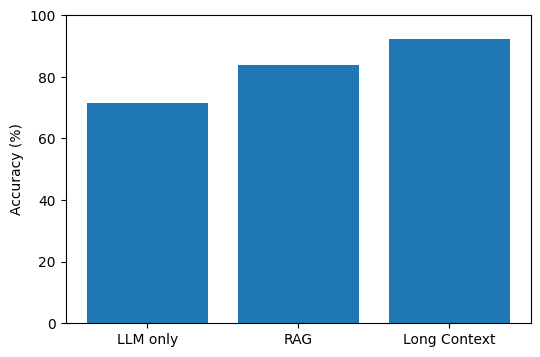

In [69]:
models = ["LLM only", "RAG", "Long Context"]
accuracy = [71.5, 83.94, 92.23]

plt.figure(figsize=(6,4))
plt.bar(models, accuracy)
plt.ylabel("Accuracy (%)")
plt.ylim(0, 100)
plt.show()

Retrieval improves performance by 12.44 points compared to the LLM-only setup. The long-context setting outperforms RAG by about 8 points. This confirms that the dataset is context-dependent, as the LLM-only approach is not sufficient. The long-context setup can be considered an upper bound. However, RAG does not reach the performance of the long-context setup, suggesting a limitation either in the retrieval or in the ranking stage. A first conclusion is that retrieval introduces an information bottleneck that limits performance compared to the long-context setting.

### 6.2 Top-K retrieval

In [62]:
data = {
    "Top-k": [1, 3, 5],
    "Accuracy (%)": [80.31, 83.94, 87.05],
    "Mean Recall": [0.2953, 0.5181, 0.5596],
    "Mean MRR": [0.2953, 0.3929, 0.4020],
    "Mean NDCG": [0.2953, 0.4251, 0.4418],
}

df = pd.DataFrame(data)
df

,Top-k,Accuracy (%),Mean Recall,Mean MRR,Mean NDCG
0,1,80.31,0.2953,0.2953,0.2953
1,3,83.94,0.5181,0.3929,0.4251
2,5,87.05,0.5596,0.4020,0.4418


There is a large improvement from Top-1 to Top-3. From Top-3 to Top-5, the gain is small. This suggests that the correct chunk is often among the top 3 results. Increasing K beyond 3 leads to diminishing returns. Overall, the retrieval performance is decent but not excellent. Accuracy increases more slowly than recall. We can conclude that the model does not always effectively exploit the retrieved chunks.

### 6.3 Chunk size

In [71]:
data = {
    "Chunk size": [300, 256],
    "Accuracy (%)": [82.38, 83.94],
    "Mean Recall": [0.4663, 0.5181],
    "Mean MRR": [0.3506, 0.3929],
    "Mean NDCG": [0.3805, 0.4251],
}

df = pd.DataFrame(data)
df

,Chunk size,Accuracy (%),Mean Recall,Mean MRR,Mean NDCG
0,300,82.38,0.4663,0.3506,0.3805
1,256,83.94,0.5181,0.3929,0.4251


Recall and ranking performance worsen with 300 token chunks. This suggests that larger chunks dilute the information. Smaller chunks are better able to capture more fine-grained information.

### 6.4 Overlap

In [61]:
data = {
    "Overlap": [0, 50, 100],
    "Accuracy (%)": [84.46, 83.94, 84.97],
    "Mean Recall": [0.4560, 0.5181, 0.5285],
    "Mean MRR": [0.3420, 0.3929, 0.3903],
    "Mean NDCG": [0.3712, 0.4251, 0.4257],
}

df = pd.DataFrame(data)
df

,Overlap,Accuracy (%),Mean Recall,Mean MRR,Mean NDCG
0,0,84.46,0.4560,0.3420,0.3712
1,50,83.94,0.5181,0.3929,0.4251
2,100,84.97,0.5285,0.3903,0.4257


Recall increases with overlap. This suggests that overlap increases the probability of capturing the evidence. However, the impact on accuracy is modest. Overall, overlap helps retrieval, but it is not the main limiting factor.

### 6.5 Embedding models

In [60]:
data = {
    "Model": ["MiniLM", "MPNet"],
    "Accuracy (%)": [84.97, 83.94],
    "Mean Recall": [0.4974, 0.5181],
    "Mean MRR": [0.4076, 0.3929],
    "Mean NDCG": [0.4304, 0.4251],
}

df = pd.DataFrame(data)
df

,Model,Accuracy (%),Mean Recall,Mean MRR,Mean NDCG
0,MiniLM,84.97,0.4974,0.4076,0.4304
1,MPNet,83.94,0.5181,0.3929,0.4251


MiniLM has lower recall but higher accuracy. This is an interesting result. MiniLM retrieves the correct chunk less often, but when it does, it ranks it better, resulting in a higher MRR.

### 6.6 Reranking

In [59]:
data = {
    "Setting": ["No reranking", "With reranking"],
    "Accuracy (%)": [83.94, 90.67],
    "Mean Recall": [0.5181, 0.7824],
    "Mean MRR": [0.3929, 0.4265],
    "Mean NDCG": [0.4251, 0.5080],
}

df = pd.DataFrame(data)
df

,Setting,Accuracy (%),Mean Recall,Mean MRR,Mean NDCG
0,No reranking,83.94,0.5181,0.3929,0.4251
1,With reranking,90.67,0.7824,0.4265,0.5080


Recall increases from about 0.52 to 0.78, while accuracy increases from 83.94% to 90.67%. The main limitation is not the generator, but the ranking stage. The reranker significantly reduces the gap with the long-context setup, suggesting that the bottleneck of the baseline lies in the ranking of the chunks rather than in the capabilities of the LLM.

### 6.7 Cleaning

In [57]:
data = {
    "Setting": ["Cleaning", "No Cleaning"],
    "Accuracy (%)": [83.94, 86.01],
    "Mean Recall": [0.5181, 0.5233],
    "Mean MRR": [0.3929, 0.3981],
    "Mean NDCG": [0.4251, 0.4304],
}

df = pd.DataFrame(data)
df

,Setting,Accuracy (%),Mean Recall,Mean MRR,Mean NDCG
0,Cleaning,83.94,0.5181,0.3929,0.4251
1,No Cleaning,86.01,0.5233,0.3981,0.4304


This is counterintuitive. It could be statistical noise.

### 6.8 LLM Size

In [55]:
data = {
    "Model": ["LLM 32B", "LLM 4B"],
    "Accuracy (%)": [90.67, 83.94],
    "Mean Recall": [0.4974, 0.5181],
    "Mean MRR": [0.4076, 0.3929],
    "Mean NDCG": [0.4304, 0.4251],
}

df = pd.DataFrame(data)
df

,Model,Accuracy (%),Mean Recall,Mean MRR,Mean NDCG
0,LLM 32B,90.67,0.4974,0.4076,0.4304
1,LLM 4B,83.94,0.5181,0.3929,0.4251


Recall is practically the same. However, another consideration can be made: large LLMs and reranking achieve the same accuracy. One improves retrieval, while the other improves generation. The large LLM used is `Qwen3-32B`.

## 7. Error analysis

To perform a qualitative analysis, we use the results obtained with the baseline, the LLM-only setup, RAG + reranker, and RAG + a 32B LLM. We focus on the 31 questions that were answered incorrectly by the baseline. For each question, we collect the correct answer, the baseline model's answer, if the correct chunk is in the top-3, the LLM-only answer, the RAG + reranker answer, and the RAG + 32B LLM answer. 

Subsequently, we assign a category to each case: retrieval failure (E1), ranking failure (E2), LLM failure (E3), or ambiguous question (E4). We follow the procedure below to assign the categories. First, we check whether the evidence is present in the top-k results. If it is absent, we label the case as a retrieval failure. If it is present, we evaluate the effect of the reranker. If the reranker corrects the answer, we classify the error as a ranking failure. Otherwise, we examine the effect of the large LLM. If it corrects the error, we attribute it to a limitation of the generator component. If none of these steps resolve the error, we categorize the question as ambiguous.

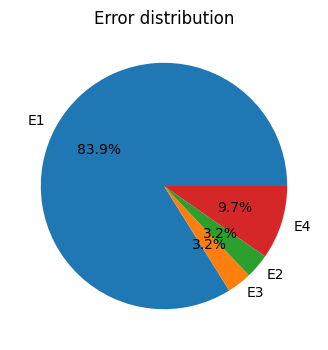

In [54]:
labels = ['E1', 'E3', 'E2', 'E4']
values = [26, 1, 1, 3]

percentages = [v / sum(values) * 100 for v in values]

plt.figure(figsize=(6, 4))
plt.pie(values, labels=labels, autopct='%1.1f%%')

plt.title('Error distribution')
plt.show()

The analysis shows that 84% of the errors made by the baseline are due to retrieval. Moreover, when the correct chunk is in the top 3, the model almost always responds correctly: 95 correct with evidence vs. 5 incorrect with evidence. The baseline is not limited by the LLM; it is almost always limited by retrieval.

```
Question 11: According to the lecture excerpt, what is the second characteristic of upper ontologies?

A: They should be applicable to almost any special domain.
B: They should be able to combine different upper ontologies without incurring inconsistency. 
C: They must be specific to a single domain.
D: They should be unable to be combined with other ontologies.
```

The model answers correctly without retrieval, but makes mistakes when retrieval is used. It therefore seems to be caused by distraction from the context. In addition, the "second characteristic" is ambiguous, as there is no canonical order for the characteristics of the upper ontologies.

```
Question 15: Which of the following event orders is possible in the second process representation but not in the first, as described in the lecture?

A: The order is delivered, then the delay notification is sent.
B: The order is delivered, and the delay notification is never sent. 
C: The delay notification is sent, then the order is delivered.
D: The delay notification is sent immediately after order preparation.
```

None of the systems predict the answers correctly. The 32B model changes its answer, but it remains incorrect. This is not a limitation of the LLM. Likewise, without context about what the "first" and "second" representations are, it is impossible to determine which event orders are feasible. The question seems to assume that you are looking at two diagrams or you are missing some information. Without that, it is unsolvable. E4.

```
Question 182: What is the main purpose of using positive pointwise mutual information (PPMI) when reweighting word vectors in the described method?

A: To increase the influence of rare words beyond what PMI would allow.
B: To smooth the probability estimates by raising them to a fractional power. 
C: To obtain word vectors that are independent of the documents.
D: To reduce dimensionality by selecting only the most frequent word pairs.
```

PMI measures the association between two words based on their co-occurrence in a corpus. 

$\text{PPMI} = \max(\text{PMI}, 0)$,

so it zeroes negative associations. In other words, we could say that answer A is plausible, while answer C, although correct, is not the main motivation. Given that all the models fail and there is some ambiguity, we can place it in category E4.

## 8. NIAH

If today's LLMs support context windows on the order of 100K tokens, or up to 1M tokens in state-of-the-art models, is retrieval still really necessary? Since a lecture is about 15K tokens long, it is technically possible to include multiple lectures in the prompt and perform QA without RAG. This leads to a provocative question: "What can be achieved without retrieval?"

To answer this rigorously, we designed a Needle-in-a-Haystack (NIAH) benchmark. We inserted a piece of information (the "needle") into a randomly selected lecture within a collection of lectures of increasing size (the "haystack"). We then compared the performance of an LLM against a RAG. We constructed datasets containing 1, 4, 8, 32, 64, and 107 lectures (the maximum available). In these settings, the needle was placed in the middle of the target lecture (50%). Additionally, we evaluated the needle placed near the beginning (10%) and near the end (90%) using collections of size 6. Finally, we implemented two scripts: one for dataset generation and one for running the evaluation. As evaluation metrics, we used Exact Match and Recall@K. The needle was:

```
The secret code for this lecture is ALPHA-7392-BETA.
```

The first trade-off concerns LLMs. A single lecture easily fits within a 128K token context window, but not all 107 lectures. Even with state-of-the-art models, such as Gemini 3 Pro, the context window reaches only about 1M tokens, which corresponds to approximately sixty lectures. Therefore, we limited our experiments to the model's context window constraints. In the case of the LLM-only setup, this resulted in a maximum of around eight lectures. For RAG, we faced another limitation. The system failed to retrieve the chunk containing the needle, even though it was correctly indexed in Chroma. We verified that the chunk could be retrieved, but its cosine similarity was close to 0. This was not due to a bug, but rather to a structural limitation of dense retrieval: embedding models such as `sentence-transformers/all-mpnet-base-v2` do not handle exact phrases well. The reason is that the needle is diluted within the semantic content of the chunk. To address this issue, we adopted hybrid retrieval, combining dense retrieval with BM25. We take the top 10 results from dense retrieval and the top 10 from BM25, merge them, and rerank the candidates using a CrossEncoder, returning the top 10. The CrossEncoder used is `cross-encoder/ms-marco-MiniLM-L-6-v2`.

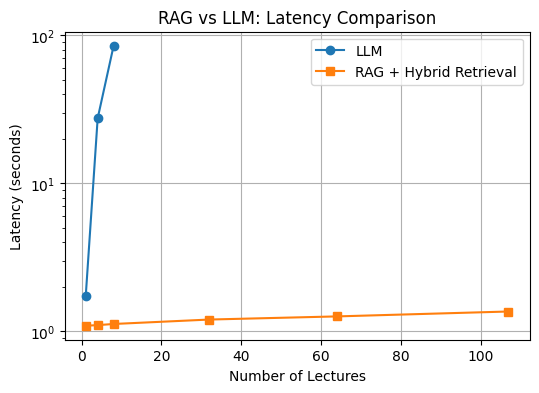

In [42]:
num_lectures = [1, 4, 8, 32, 64, 107]
llm_latency = [1.72, 27.49, 85.07, None, None, None] # None where it wasn't feasible
rag_latency = [1.09, 1.10, 1.12, 1.20, 1.26, 1.36]

plt.figure(figsize=(6, 4))
plt.plot(num_lectures[:3], llm_latency[:3], marker='o', label='LLM')
plt.plot(num_lectures, rag_latency, marker='s', label='RAG + Hybrid Retrieval')

plt.xlabel('Number of Lectures')
plt.ylabel('Latency (seconds)')
plt.title('RAG vs LLM: Latency Comparison')
plt.legend()
plt.grid()
plt.yscale('log')
plt.show()

One aspect that immediately stands out is the response time. As the number of lectures increases, the LLM takes progressively longer to generate an answer. The LLM was able to find the needle in all cases. In contrast, the RAG system shows much more stable response times. In this setting as well, the needle is always found.

## 9. Conclusions

This project aimed to investigate whether a RAG system is able to answer university exam-style questions based on lecture transcripts. The results showed that RAG significantly improves accuracy compared to using only the LLM. However, the experiments also highlighted that the main bottleneck is not the capability of the generative model, but the retrieval component. When the correct chunk is retrieved, even small local LLMs achieve high accuracy, whereas most errors are related to the retrieval stage failing to find the right chunk. In this sense, recent progress has led to the development of LLMs with very large context windows, which provide an upper bound on performance, but their limitations are scalability and latency. The Needle-in-a-Haystack experiments further confirm that dense retrieval alone is not sufficient. It is therefore necessary to adopt hybrid approaches that combine dense and sparse retrieval. Overall, these findings suggest that RAG can "pass an AI class" with appropriate design choices. In the future, it would be possible to develop a multimodal RAG system incorporating slides either as text or as images, using multimodal embeddings.

## References

[[1](https://www.unibo.it/en/study/course-units-transferable-skills-moocs/course-unit-catalogue/course-unit/2024/491926)] Moro, G. (2023–2024). Big Data Analytics and Text Mining – Lecture Slides. University of Bologna. \
[[2](https://arxiv.org/abs/2212.04356)] Radford, A., Kim, J. W., Xu, T., Brockman, G., McLeavey, C., & Sutskever, I. (2023). Robust Speech Recognition via Large-Scale Weak Supervision. In Proceedings of the International Conference on Machine Learning (ICML). \
[[3](https://arxiv.org/abs/2005.11401)] Lewis, P., Perez, E., Piktus, A., Petroni, F., Karpukhin, V., Goyal, N., Küttler, H., Lewis, M., Yih, W.-T., Rocktäschel, T., Riedel, S., & Kiela, D. (2020). Retrieval-Augmented Generation for Knowledge-Intensive NLP Tasks. In Advances in Neural Information Processing Systems (NeurIPS). \
[[4](https://arxiv.org/abs/2004.04906)] Karpukhin, V., Oguz, B., Min, S., Lewis, P., Wu, L., Edunov, S., Chen, D., & Yih, W.-T. (2020). Dense Passage Retrieval for Open-Domain Question Answering. In Proceedings of the Conference on Empirical Methods in Natural Language Processing (EMNLP). \
[[5](https://arxiv.org/abs/2007.01282)] Izacard, G., & Grave, E. (2021). Leveraging Passage Retrieval with Generative Models for Open Domain Question Answering. In Proceedings of the European Chapter of the Association for Computational Linguistics (EACL). \
[[6](https://proceedings.neurips.cc/paper/2020/hash/c3a690be93aa602ee2dc0ccab5b7b67e-Abstract.html)] Song, K., Tan, X., Qin, T., Lu, J., & Liu, T.-Y. (2020). MPNet: Masked and Permuted Pre-training for Language Understanding. In Advances in Neural Information Processing Systems (NeurIPS). \
[[7](https://arxiv.org/abs/2002.10957)] Wang, W., Wei, F., Dong, L., Bao, H., Yang, N., & Zhou, M. (2020). MiniLM: Deep Self-Attention Distillation for Task-Agnostic Compression of Pre-Trained Transformers. In Advances in Neural Information Processing Systems (NeurIPS). \
[[8](https://arxiv.org/abs/1901.04085)] Nogueira, R., & Cho, K. (2019). Passage Re-ranking with BERT. arXiv preprint arXiv:1901.04085. \
[[9](https://dl.acm.org/doi/abs/10.1561/1500000019)] Robertson, S., & Zaragoza, H. (2009). The Probabilistic Relevance Framework: BM25 and Beyond. Foundations and Trends in Information Retrieval, 3(4), 333–389. \
[[10](https://github.com/ggerganov/llama.cpp)] Gerganov, G. (2023). llama.cpp: Port of LLaMA model in C/C++.